#Requirements

In [3]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
import json
from skimage.exposure import match_histograms
import imagehash
from shapely.geometry import Polygon
from PIL import Image
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from keras import backend as K

# Dataset Pre-processing

In [4]:
def apply_threshold(img_gray):
  ret, thresh = cv.threshold(img_gray, 250.00, 255.00, int(cv.THRESH_OTSU))
  # plt.imshow(cv.cvtColor(thresh, cv.COLOR_BGR2RGB))
  # plt.title('After applying OTSU threshold')
  # plt.show()
  return thresh

In [5]:
def hist_equ(image):

    size = image.shape[0:2]
    image_size = size[0]*size[1]
    L = 256

    unique, counts = np.unique(image, return_counts=True)
    pxl_count = dict(zip(unique, counts))

    key = [*pxl_count]
    key.sort() # we can remove this line
    list_sum = [] # sigma (𝑛𝑗 / 𝑛)
    counter = 0

    new_pxl = {}
    
    for item in key:
        counter += pxl_count[item]
        new_pxl.update({item:int((counter/image_size) * (L-1))})


    # print(len(image[0]))
    for row in range(size[0]):
        for col in range(size[1]):
            image[row][col] = new_pxl[image[row][col]]

    return image

In [6]:
def morphology(img_binary, kernel = np.ones((35, 35), np.uint8)):
  opening = cv.morphologyEx(img_binary, cv.MORPH_OPEN, kernel)
  closing = cv.morphologyEx(opening, cv.MORPH_CLOSE, kernel)
  # plt.imshow(cv.cvtColor(closing, cv.COLOR_BGR2RGB))
  # plt.title('After applying morphology transformation')
  # plt.show()
  return closing

In [7]:
def crop_image(img, img_binary):
  temp = np.where(img_binary==255)
  crop_indexes = min(temp[0]) + 5, min(temp[1]) + 5
  mask = img_binary==255
  img_cropped = img[np.ix_(mask.any(1), mask.any(0))]
  img_cropped = img_cropped[5:-5, 5:-5]
  # plt.imshow(cv.cvtColor(img_cropped, cv.COLOR_BGR2RGB))
  # plt.title('After cropping_image')
  # plt.show()
  return img_cropped, crop_indexes

In [8]:
def histogram_matching(img_cropped, pattern):
  m = match_histograms(img_cropped, pattern)
  # plt.imshow(cv.cvtColor(m, cv.COLOR_BGR2RGB))
  # plt.title('After histogram matching')
  # plt.show()
  return m

In [9]:
def rotate_finder(img_matched,pattern_resized):
    simil = []
    
    im_pil1 = Image.fromarray(img_matched)
    hash = imagehash.average_hash(im_pil1)
    rotate = [None,cv.ROTATE_90_CLOCKWISE,cv.ROTATE_180,cv.ROTATE_90_COUNTERCLOCKWISE]

    
    for angle in rotate:
        if angle != None:
            img = cv.rotate(pattern_resized, angle)
            im_pil2 = Image.fromarray(img)
            hash_ = imagehash.average_hash(im_pil2)
            simil.append(hash - hash_)
        else:
            im_pil2 = Image.fromarray(pattern_resized)
            hash_ = imagehash.average_hash(im_pil2)
            simil.append(hash - hash_)
    indx = rotate[simil.index(min(simil))]
    hold = cv.rotate(pattern_resized, indx)
    
    if hold.shape[0] != img_matched.shape[0]:
        hold = cv.resize(hold, (hold.shape[1], hold.shape[0]))
    
    return hold
    

In [10]:
def extract_pattern(img_name):
    json_name = img_name[:-3] + "json"
    f = open(json_name, encoding="utf8")
    data = json.load(f)
    f.close()
    pattern = cv.imread('Patterns/' + data['pattern'])
    return pattern

In [11]:
def find_label(img_name,i,window_size_height, j,window_size_width,main):
    not_main = Polygon([(i,j),(i+window_size_height,j),(i+window_size_height,j+window_size_width),(i,j+window_size_width)]).buffer(0)
    Flag = 0
    inter = not_main.intersection(main).area
    if inter > 0:
        return 1
    return 0

In [12]:
def window_sliding(img, pattern, img_name, crop_indexes, window_size_height=120, window_size_width=120):
  images, patterns, labels = [], [], []
  height, width= img.shape
  point_list = []
  json_name = img_name[:-3] + "json"
  f = open(json_name, encoding="utf8")
  data = json.load(f)
  f.close()
  for shape in data["shapes"]:
    points = np.array(shape['points']) - crop_indexes
    for pxl in points:
        point_list.append((int(pxl[0]),int(pxl[1])))
  main = Polygon(point_list).buffer(0)
        
  for i in range(0, height-window_size_height, window_size_height):
    for j in range(0, width-window_size_width, window_size_width):
      # cv.imwrite(dir +'/' + str(i)+str(j)+'_img_'+img_name, img_part)
      # cv.imwrite(dir +'/' + str(i)+str(j)+'_pattern_'+img_name, pattern_part)
      temp = pattern[i:i+window_size_height, j:j+window_size_width]
      if temp.shape==(window_size_height,window_size_width):
        patterns.append(temp)
        images.append(img[i:i+window_size_height, j:j+window_size_width])
        labels.append(find_label(img_name,i,window_size_height, j,window_size_width,main))
  return images, patterns, labels

In [13]:
def save_image(img_name, img_matched, pattern_resized_rotate, crop_indexes, dir='Customized_Dataset/'):
  if not os.path.exists(dir):
    os.mkdir(dir)
  json_name = img_name[:-3] + "json"
  f = open(json_name, encoding="utf8")
  data = json.load(f)
  f.close()
  img_name = img_name.replace('Dataset/', '')
  new_json_name = dir + img_name[:-4] + '_customized' + ".json"
  for i in range(len(data["shapes"])):
    data['shapes'][i]['points'] = np.array(data['shapes'][i]['points']) - crop_indexes
    data['shapes'][i]['points'] = data['shapes'][i]['points'].tolist()
  with open(new_json_name, 'w') as fp:
        json.dump(data, fp)
  
  cv.imwrite(dir + 'train/customized_img_'+img_name, img_matched)
  cv.imwrite(dir + 'pattern/customized_pattern_'+img_name, pattern_resized_rotate)

In [17]:
def pre_processing(img_name,Kernel_size = 120):
  img = cv.imread(img_name).astype('uint8')
  img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
  img_binary = apply_threshold(img_gray)
  img_binary = morphology(img_binary)
  img_cropped, crop_indexes = crop_image(img, img_binary)
  pattern = extract_pattern(img_name)
  pattern =  cv.equalizeHist(cv.cvtColor(pattern, cv.COLOR_BGR2GRAY))
  img_matched = histogram_matching(cv.equalizeHist(cv.cvtColor(img_cropped, cv.COLOR_BGR2GRAY)), pattern)
  pattern_resized = cv.resize(pattern, (img_matched.shape[1], img_matched.shape[0]))
  pattern_resized_rotate = rotate_finder(img_matched,pattern_resized)
  save_image(img_name, img_matched, pattern_resized_rotate, crop_indexes)
  images, patterns, labels = window_sliding(img_matched, pattern_resized_rotate, img_name, crop_indexes,Kernel_size,Kernel_size)
  return images,patterns,labels

In [18]:
images, patterns, labels = [], [], []
j=0
for img in os.listdir('Dataset'):
    if (img.endswith(".jpg")) | (img.endswith(".png")):
        i,p,l = pre_processing('Dataset/' + img)
        images.extend(i)
        patterns.extend(p)
        labels.extend(l)
        j += 1
        print(j, 'done!')
    # if j==5:
    #     break

1 done!
2 done!
3 done!
4 done!
5 done!
6 done!
7 done!
8 done!
9 done!
10 done!
11 done!
12 done!
13 done!
14 done!
15 done!
16 done!
17 done!
18 done!
19 done!
20 done!
21 done!
22 done!
23 done!
24 done!
25 done!
26 done!
27 done!
28 done!
29 done!
30 done!
31 done!
32 done!
33 done!
34 done!
35 done!
36 done!
37 done!
38 done!
39 done!
40 done!
41 done!
42 done!
43 done!
44 done!
45 done!
46 done!
47 done!
48 done!
49 done!
50 done!
51 done!
52 done!
53 done!
54 done!
55 done!
56 done!
57 done!
58 done!
59 done!
60 done!
61 done!
62 done!
63 done!
64 done!
65 done!
66 done!
67 done!
68 done!
69 done!
70 done!
71 done!
72 done!
73 done!
74 done!
75 done!
76 done!
77 done!
78 done!
79 done!
80 done!
81 done!
82 done!
83 done!
84 done!
85 done!
86 done!
87 done!
88 done!
89 done!
90 done!
91 done!
92 done!
93 done!
94 done!
95 done!
96 done!
97 done!
98 done!
99 done!
100 done!
101 done!
102 done!
103 done!
104 done!
105 done!
106 done!
107 done!
108 done!
109 done!
110 done!
111 done

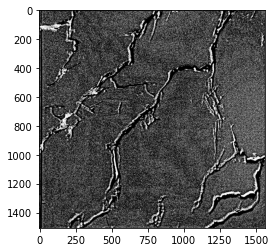

In [47]:
# for file_name in os.listdir('Customized_Dataset/train/'):
file_name = 'customized_img_1644398600.9163294.jpg'
if (file_name.endswith(".jpg") or file_name.endswith(".png")):
    t1 = cv.imread('Customized_Dataset/train/' + file_name, cv.IMREAD_GRAYSCALE)
    pattern_name = file_name.replace('img', 'pattern')
    t2 = cv.imread('Customized_Dataset/pattern/'+ pattern_name, cv.IMREAD_GRAYSCALE)
    t2 = rotate_finder(t1, t2)
    if t1.shape[0] != t2.shape[0]:
        t2 = cv.resize(t2, (t2.shape[0], t2.shape[1]))
    t1 = cv.adaptiveThreshold(t1, 
                              255, 
                              cv.ADAPTIVE_THRESH_MEAN_C, 
                              cv.THRESH_BINARY, 
                              31, 
                              10)
    t2 = cv.adaptiveThreshold(t2, 
                              255, 
                              cv.ADAPTIVE_THRESH_MEAN_C, 
                              cv.THRESH_BINARY, 
                              31, 
                              10)
    temp = t1 - t2
    plt.imshow(temp, cmap='gray')
        # break

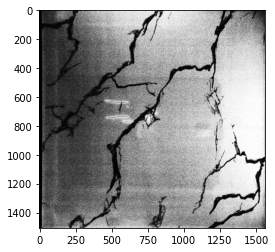

In [45]:
plt.imshow(t1, cmap='gray')

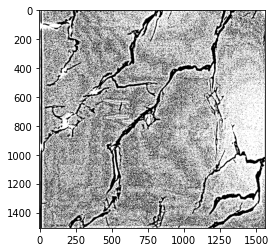

In [48]:
plt.imshow(t1, cmap='gray')

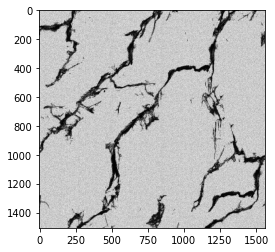

In [46]:
plt.imshow(t2, cmap='gray')

# Model

In [67]:
def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + 
    K.epsilon())
    return recall

def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1_score_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

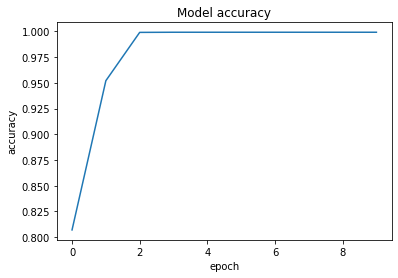

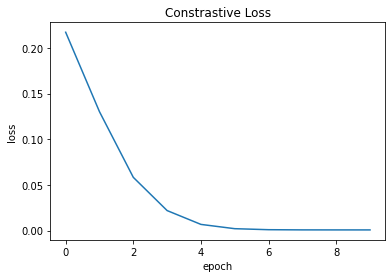

In [24]:
def plt_metric(history, metric, title, has_valid=False):
    """Plots the given 'metric' from 'history'.

    Arguments:
        history: history attribute of History object returned from Model.fit.
        metric: Metric to plot, a string value present as key in 'history'.
        title: A string to be used as title of plot.
        has_valid: Boolean, true if valid data was passed to Model.fit else false.

    Returns:
        None.
    """
    plt.plot(history[metric])
    if has_valid:
        plt.plot(history["val_" + metric])
        plt.legend(["train", "validation"], loc="upper left")
    plt.title(title)
    plt.ylabel(metric)
    plt.xlabel("epoch")
    plt.show()


# Plot the accuracy
plt_metric(history=history.history, metric="accuracy", title="Model accuracy")

# Plot the constrastive loss
plt_metric(history=history.history, metric="loss", title="Constrastive Loss")

In [ ]:
predictions = siamese.predict([x_test_1, x_test_2])
visualize(pairs_test, labels_test, to_show=3, predictions=predictions, test=True)